In [2]:
%pip install langchain langchain-groq langchain-community langgraph python-dotenv faiss-cpu pypdf sentence-transformers

  Using cached langchain-1.2.17-py3-none-any.whl.metadata (5.8 kB)
  Using cached faiss_cpu-1.13.2-cp310-abi3-macosx_14_0_arm64.whl.metadata (7.6 kB)
  Using cached pypdf-6.10.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached langgraph-1.1.10-py3-none-any.whl.metadata (8.0 kB)
  Using cached langgraph_prebuilt-1.0.13-py3-none-any.whl.metadata (5.2 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached safetensors-0.7.0-cp38-abi3-macosx_11_0_arm64.whl.metadata (4.1 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached

In [5]:
from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

/opt/homebrew/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [6]:
load_dotenv()


True

In [7]:
import os
llm = ChatGroq(model="llama-3.3-70b-versatile",temperature=0, groq_api_key=os.getenv("GROQ_API_KEY"))

In [8]:
loader = PyPDFLoader("islr.pdf")
docs = loader.load()

In [9]:
len(docs)

441

In [10]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [11]:
len(chunks)

1308

In [12]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(chunks,embeddings)

/var/folders/0d/2kwkrk3j5j373ss9sbf8sd6m0000gn/T/ipykernel_30631/3967677144.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11291.22it/s]


In [13]:
vector_store

In [19]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={'k': 4})

In [21]:
len(retriever.invoke('What is ISLR?'))

4

In [30]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    use this tool when the user asks factual/conceptual questions
    that might be answered from the stored documents.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return{
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [31]:
tools =[rag_tool]
llm_with_tools = llm.bind_tools(tools)



In [32]:

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


In [33]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}


In [34]:
tool_node = ToolNode(tools)


In [35]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()


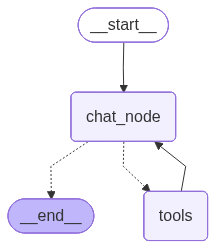

In [36]:

chatbot


In [37]:

result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain the method and idea behind Linear Regression"
                )
            )
        ]
    }
)

In [38]:

print(result['messages'][-1].content)


The method and idea behind Linear Regression is to model the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the data. The linear regression model assumes a straight-line relationship between the predictors and the response, and the goal is to estimate the parameters of the linear equation that best fit the data. The most common approach to fitting the linear model is referred to as ordinary least squares, which involves finding the values of the parameters that minimize the sum of the squared errors between the observed responses and the predicted responses. However, other approaches, such as non-linear extensions of the linear model, can also be used. Potential problems that may occur when fitting a linear regression model include non-linearity of the response-predictor relationships, correlation of error terms, non-constant variance of error terms, outliers, high-leverage points, and collinearity.
